# [3920] Multi-model
Data file: https://raw.githubusercontent.com/vjavaly/Baruch-CIS-3920/main/data/liver_cirrhosis_stage_10K.csv

### Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Add other imports as needed
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

### Load data

Liver Cirrhosis Stage Classification

Context
> Cirrhosis results from prolonged liver damage, leading to extensive scarring, often due to conditions like hepatitis or chronic alcohol consumption.

Data source
> Mayo Clinic study on primary biliary cirrhosis (PBC) of the liver carried out from 1974 to 1984.


Features
* N_Days : # days between registration and the earlier of death, transplantation, or study analysis time in 1986
* Status : patient status - values = C (censored), CL (censored due to liver tx), or D (death)
* Drug : type of drug given (D-penicillamine) or placebo
* Age : patient age (days)
* Gender : M (male) or F (female)
* Ascites : presence of ascites N (No) or Y (Yes)
* Hepatomegaly : presence of hepatomegaly N (No) or Y (Yes)
* Spiders : presence of spiders N (No) or Y (Yes)
* Edema : presence of edema N (no edema and no diuretic therapy for edema), S (edema present without diuretics, or edema resolved by diuretics), or Y (edema despite diuretic therapy)
* Bilirubin : serum bilirubin in [mg/dl]
* Cholesterol : serum cholesterol in [mg/dl]
* Albumin : albumin in [gm/dl]
* Copper : urine copper in [ug/day]
* Alk_Phos : alkaline phosphatase in [U/liter]
* SGOT : serum glutamic-oxaloacetic transaminase, an enzyme level indicating liver health in [U/ml]
* Tryglicerides : triglicerides in [mg/dl]
* Platelets : platelets per cubic [ml/1000]
* Prothrombin : prothrombin time in seconds [s]
* Patient_ID : patient ID

Target variable to predict:
* Disease_Stage: stage_1, stage_2, stage_3

In [ ]:
# Read data from file (liver_cirrhosis_stage_10K.csv) into dataframe
#  NOTES:
#   Field separator is ';'
#   Use column 'Patient_ID' as index_col
df = pd.read_csv(
    'https://raw.githubusercontent.com/vjavaly/Baruch-CIS-3920/main/data/liver_cirrhosis_stage_10K.csv',sep=';',
    index_col='Patient_ID')

### Examine data

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
# Review dataframe shape
df.shape

(10000, 19)

In [ ]:
# Display a sample of 5 rows from dataframe
df.sample(5)

,N_Days,Status,Drug,Age,Gender,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage
Patient_ID,,,,,,,,,,,,,,,,,,,
11505,2170.0,C,D-penicillamine,22514.0,F,N,N,N,N,0.5,369.510563,3.89,29.000000,897.000000,66.650000,124.702128,514.0,10.0,stage_1
14526,1702.0,C,D-penicillamine,18806.0,F,N,N,N,N,1.1,414.000000,3.44,80.000000,1003.000000,99.000000,55.000000,270.0,9.6,stage_1
5503,1328.0,C,Placebo,14610.0,F,Y,N,Y,N,0.5,369.510563,3.65,97.648387,1982.655769,122.556346,124.702128,337.0,10.4,stage_3
9322,1447.0,CL,Placebo,19724.0,F,Y,N,Y,N,1.6,369.510563,3.07,136.000000,1995.000000,128.000000,124.702128,286.0,13.1,stage_3
22312,1212.0,D,Placebo,12963.0,F,N,N,N,N,1.3,408.000000,4.22,67.000000,1387.000000,142.600000,137.000000,295.0,10.1,stage_2


### Display bar chart showing class distribution for target variable (Disease_Stage)

In [ ]:
# Display class distribution counts
df.Disease_Stage.value_counts()

,count
Disease_Stage,
stage_2,3416
stage_1,3307
stage_3,3277


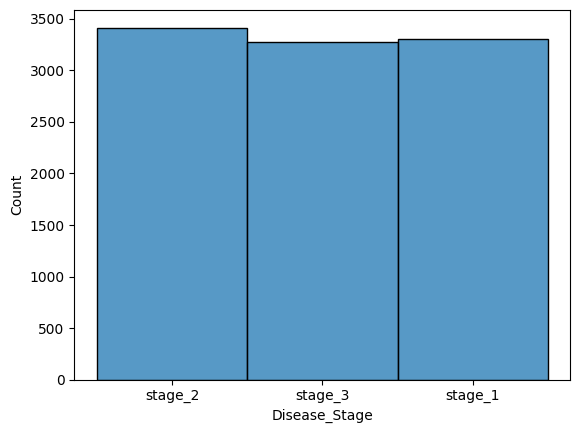

In [ ]:
# Display bar chart showing class distribution
sns.histplot(df.Disease_Stage)
plt.show()

### Prepare data for model training
* Do not delete any rows
* Do not drop any columns, EXCEPT when performing variable encoding

#### Check for missing values

In [ ]:
df.isnull().sum()

,0
N_Days,18
Status,107
Drug,0
Age,25
Gender,44
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


#### Use the SimpleImputer to replace missing values

In [ ]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [ ]:
df['N_Days'] = imp_mean.fit_transform(df[['N_Days']])

In [ ]:
df['Age'] = imp_mean.fit_transform(df[['Age']])

In [ ]:
imp_most_freq = SimpleImputer(strategy='most_frequent')

In [ ]:
df['Status'] = imp_most_freq.fit_transform(df[['Status']]).ravel()

In [ ]:
df['Gender'] = imp_most_freq.fit_transform(df[['Gender']]).ravel()

#### Check for missing values again

In [ ]:
df.isnull().sum()

,0
N_Days,0
Status,0
Drug,0
Age,0
Gender,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


### Perform one-hot encoding

In [ ]:
cols_to_encode = ['Status','Drug','Gender','Ascites','Hepatomegaly', 'Spiders', 'Edema']

In [ ]:
df = pd.get_dummies(df, columns=cols_to_encode, dtype=int)

In [ ]:
df.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage,Status_C,Status_CL,Status_D,Drug_D-penicillamine,Drug_Placebo,Gender_F,Gender_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y
Patient_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10481,2772.0,16071.0,0.6,217.0,3.62,13.0,414.0,75.95,119.0,292.0,10.2,stage_2,1,0,0,0,1,0,1,0,1,1,0,0,1,1,0,0
19109,1234.0,21185.0,6.4,373.0,3.46,155.0,1768.0,120.00,151.0,109.0,10.4,stage_3,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0,0
14801,1349.0,12285.0,2.2,572.0,3.77,77.0,2520.0,92.00,114.0,226.0,11.7,stage_3,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,0
22491,4196.0,17841.0,1.2,258.0,3.57,79.0,2201.0,120.90,76.0,410.0,11.5,stage_3,1,0,0,0,1,1,0,1,0,0,1,1,0,1,0,0
8594,2443.0,16050.0,0.9,308.0,3.69,67.0,696.0,51.15,101.0,278.0,9.9,stage_3,1,0,0,0,1,1,0,1,0,0,1,1,0,1,0,0


### Perform label encoding

In [ ]:
le = LabelEncoder()

In [ ]:
df['Disease_Stage']= le.fit_transform(df['Disease_Stage'])

### Separate independent and dependent variables
* Independent variables: All variables EXCEPT Disease_Stage
* Dependent variable: Disease_Stage

In [ ]:
X = df.drop('Disease_Stage', axis = 1)
y = df['Disease_Stage']

#### Standardize the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.80718366, -0.64655844, -0.59037154, ...,  0.47849155,
        -0.41081681, -0.2091229 ],
       [-0.60352803,  0.72150998,  0.63817029, ...,  0.47849155,
        -0.41081681, -0.2091229 ],
       [-0.49804568, -1.65936779, -0.25146345, ...,  0.47849155,
        -0.41081681, -0.2091229 ],
       ...,
       [-0.2531432 ,  2.38250661, -0.25146345, ..., -2.08990108,
         2.43417496, -0.2091229 ],
       [-1.17496716, -0.48952751, -0.29382696, ..., -2.08990108,
         2.43417496, -0.2091229 ],
       [ 0.12934495,  1.94859833,  0.02389937, ...,  0.47849155,
        -0.41081681, -0.2091229 ]])

### Display a sample of 20 rows of the final set of independent variables used for all the model trainings

In [ ]:
X.sample(20)

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Status_C,Status_CL,Status_D,Drug_D-penicillamine,Drug_Placebo,Gender_F,Gender_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y
Patient_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
5542,989.0,12784.0,0.7,280.000000,3.23,97.648387,1093.000000,128.650000,81.000000,312.00000,10.8,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0,0
8151,2111.0,19723.0,1.0,369.510563,3.60,97.648387,1982.655769,122.556346,124.702128,257.02457,12.1,0,0,1,0,1,1,0,0,1,1,0,0,1,1,0,0
24505,460.0,16658.0,5.0,325.000000,3.47,110.000000,2460.000000,246.450000,56.000000,430.00000,11.9,0,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0
11027,3820.0,22767.0,1.8,460.000000,3.35,148.000000,1472.000000,108.500000,118.000000,234.00000,10.2,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0
21624,4256.0,16034.0,0.6,216.000000,3.94,28.000000,601.000000,60.450000,188.000000,211.00000,13.0,1,0,0,0,1,0,1,1,0,1,0,1,0,1,0,0
18454,1170.0,16658.0,1.3,369.510563,3.41,97.648387,1982.655769,122.556346,124.702128,430.00000,11.9,1,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0
23707,2330.0,10795.0,3.7,347.000000,3.90,76.000000,2544.000000,221.650000,90.000000,129.00000,11.5,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,0
15908,1443.0,15526.0,1.2,369.510563,2.80,97.648387,1982.655769,122.556346,124.702128,251.00000,11.0,1,0,0,1,0,1,0,1,0,1,0,0,1,1,0,0
24581,1427.0,11273.0,7.2,1015.000000,3.26,247.000000,3836.000000,198.400000,280.000000,330.00000,9.8,1,0,0,0,1,1,0,1,0,0,1,1,0,1,0,0


### Display a sample of 5 rows of the final set of dependent variables used for all the model trainings

In [ ]:
y.sample(5)

,Disease_Stage
Patient_ID,
14697,1
23932,1
1995,2
1692,2
7351,0


### Split data into training and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y,
                                                    test_size=0.25,
                                                    random_state=42)

### Train Logistic Regression model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
LogReg_model = LogisticRegression(max_iter= 120, solver= 'saga', penalty= 'elasticnet', C=5.6, l1_ratio= 1)
LogReg_model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=5.6, l1_ratio=1, max_iter=120, penalty='elasticnet',
                   solver='saga')

### Evaluate Logistic Regression model

In [ ]:
LogReg_predictions = LogReg_model.predict(X_test)
LogReg_accuracy = accuracy_score(y_test,LogReg_predictions )
print(f'Logistic regression accuracy = {round(accuracy_score(y_test, LogReg_predictions)*100,2)}%')

Logistic regression accuracy = 58.72%


### Train KNN classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors=10, algorithm='brute', metric='manhattan', weights='distance', leaf_size= 40)
KNN_model.fit(X_train, y_train)

KNeighborsClassifier(algorithm='brute', leaf_size=40, metric='manhattan',
                     n_neighbors=10, weights='distance')

### Evaluate KNN model

In [ ]:
KNN_pred = KNN_model.predict(X_test)
KNN_accuracy = accuracy_score(y_test, KNN_pred)
print(f"KNN accuracy = {round((KNN_accuracy * 100), 4)}%")

KNN accuracy = 90.52%


### Train Random Forest classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
RF_model = RandomForestClassifier(random_state=42, max_features= 'log2',criterion= 'gini', n_estimators= 200)
RF_model.fit(X_train, y_train)

RandomForestClassifier(max_features='log2', n_estimators=200, random_state=42)

### Evaluate Random Forest model

In [ ]:
RF_pred = RF_model.predict(X_test)
RF_accuracy = accuracy_score(y_test, RF_pred)
print(f"RF_accuracy = {round((RF_accuracy * 100), 4)}%")

RF_accuracy = 93.68%


### Train Support Vector Classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
SVC_model = SVC(C= 25.0, kernel = 'poly', gamma="auto", cache_size=100, degree= 5)
SVC_model.fit(X_train, y_train)

SVC(C=25.0, cache_size=100, degree=5, gamma='auto', kernel='poly')

### Evaluate Support Vector Classifier model

In [ ]:
SVC_model_preds = SVC_model.predict(X_test)
SVC_model_accuracy= accuracy_score(y_test, SVC_model_preds)
print(f"SVC accuracy = { round((SVC_model_accuracy * 100), 3)}%")

SVC accuracy = 83.92%


### Display bar chart comparison of accuracy for all 4 models

(0.0, 1.0)

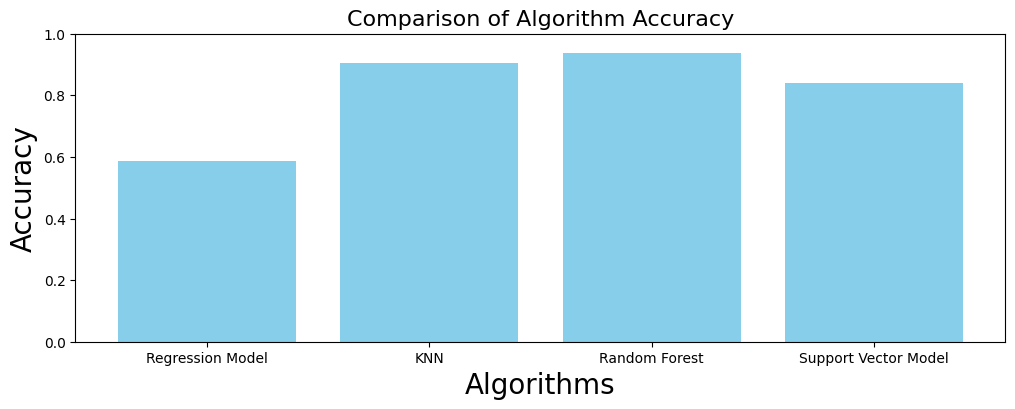

In [ ]:
plt.figure(figsize=(12, 4))
algorithms = ['Regression Model', 'KNN', 'Random Forest', 'Support Vector Model']
accuracies = [LogReg_accuracy, KNN_accuracy, RF_accuracy, SVC_model_accuracy]

plt.bar( algorithms, accuracies, color='skyblue')

plt.title('Comparison of Algorithm Accuracy', fontsize=16)
plt.xlabel('Algorithms', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.ylim(0, 1)